# Preliminary tests for all MLP, CNN, and Deeper CNN

## Group 12

In [1]:
# import relevant libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import time
from typing import Tuple, List, Dict, Optional, Any
torch.manual_seed(42)
# Reproducibility
np.random.seed(42)
# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# verify Pytorch and CUDA versions
cuda_version = torch.version.cuda
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {cuda_version}")

PyTorch version: 2.12.0.dev20260316+cu130
CUDA version: 13.0


# Load the FashionMNIST dataset

In [ ]:
# 1. Load Fashion-MNIST data

# set seed
SEED=42
torch.manual_seed(42)

print("\n1. LOADING FASHION-MNIST DATA FROM LOCAL PATH")
transform = transforms.Compose([transforms.ToTensor()])

data_path = '../'
train_dataset = datasets.FashionMNIST(root=data_path, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=data_path, train=False, download=True, transform=transform)


# split the training data into train and validation sets
val_size = 10000
gen = torch.Generator().manual_seed(SEED) # gen is needed for consistency
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size], gen)

# Create DataLoaders

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# print to see the length of the datasets
print("\n\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(test_dataset)}")

# print to see the length of the datasets
print("\n===DIMENSIONS AFTER SPLIT===")
print(f"Training samples: train_ds = {len(train_ds)}")
print(f"Validation samples: val_ds = {len(val_ds)}")
print(f"Test samples: test_dataset = {len(test_dataset)}")


1. LOADING FASHION-MNIST DATA FROM LOCAL PATH


===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 50000
Validation samples: val_ds = 10000
Test samples: test_dataset = 10000


# Build the model

In [4]:
class BaselineMLP(nn.Module):
    """
    Baseline MLP to use as baseline. This is implemented
    using 2 layers (input and output) and a hidden layer with ReLU activation function
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        activation: str = 'relu'
    ):
        super().__init__()

        self.activation_name = activation

        # Build layers
        dims = [input_dim] + hidden_dims + [output_dim]

        # From before: nn.ModuleList to store layers
        self.layers = nn.ModuleList()

        print(f"\n[MLP Architecture] Building network: {dims}")

        for i in range(len(dims) - 1):
            layer = nn.Linear(dims[i], dims[i+1])
            self.layers.append(layer)
            print(f"  Layer {i}: Linear({dims[i]} → {dims[i+1]})")

        # Activation function
        self.activation = self._get_activation(activation)


    def _get_activation(self, name: str):
        """Get activation function by name."""
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU()
        }
        return activations.get(name, nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward method. Since MLP is linear, we need to flatten the image
        before passing into the layers.
        Note that each operation creates a node in the computation graph
        """
        # Flatten image data for MLP
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        # Pass through layers
        for i, layer in enumerate(self.layers):
            # Linear transformation
            x = layer(x)

            # Check gradient function
            #if x.requires_grad and x.grad_fn is not None:
            #    print(f"  After layer {i}: grad_fn = {x.grad_fn}")

            # Apply activation (except last layer)
            if i < len(self.layers) - 1:
                x = self.activation(x)

        return x

#BaselineMLP(784, [128, 128], 10) # this is for unit testing

In [5]:
# train the model
def model_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 40, # Reduced epochs for faster demo
    learning_rate: float = 0.001,
    monitor_interval: int = 5
):
    """
    Train model. Watch how gradients behave during training
    """

    # The Loss for classification
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    # History tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        #'gradient_norms': {name: [] for name, _ in model.named_parameters()},
    }

    print(f"\n=== Training: {type(model).__name__} ===")

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        for batch_X, batch_y in train_loader:
            # Move data batch to the selected device. The model and data
            # must be on the same device to perform operations.
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_X.size(0)
            total_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
            total_samples += batch_X.size(0)

        # Record training metrics
        avg_train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)

        # Validation
        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # Move validation data to the device.
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                total_val_loss += loss.item() * batch_X.size(0)
                total_val_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
                total_val_samples += batch_X.size(0)

        # Record validation metrics
        avg_val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # Detailed monitoring
        if epoch % monitor_interval == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}: "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2%}, | "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2%}")

    return history

# create viuals
def visualize_training_results(results: Dict[str, Dict]):
    """
    Comprehensive visualization of training results.
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('MLP Architecture on Fashion-MNIST', fontsize=16)

    # 1. Training Loss curves
    ax = axes[0, 0]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_loss'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_loss'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Curves (Loss)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Training Accuracy curves
    ax = axes[0, 1]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_acc'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_acc'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training Curves (Accuracy)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3. Final performance comparison
    ax = axes[1, 0]
    names = list(results.keys())
    val_accs = [results[n]['final_val_acc'] * 100 for n in names]

    bars = ax.bar(names, val_accs, alpha=0.8)
    ax.set_ylabel('Final Validation Accuracy (%)')
    ax.set_title('Final Performance')
    ax.set_xticklabels(names, rotation=25, ha='right')
    ax.set_ylim(bottom=max(0, min(val_accs) - 10))
    ax.bar_label(bars, fmt='%.1f%%')
    ax.grid(True, alpha=0.3, axis='y')

In [6]:
def compare_architectures(train_loader: DataLoader, val_loader: DataLoader):
    """
    Compare different models: MLP architectures vs a deeper model when available.
    This is a placeholder. Will leverage this later.
    """
    print("\n" + "="*80)
    print("MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    INPUT_DIM = 28* 28  # Fashion-MNIST image height and width size
    OUTPUT_DIM = 10     # 10 classes

    architectures = {
        'MLP': BaselineMLP(
            input_dim=INPUT_DIM,
            hidden_dims=[128], # can be two. A reasonably sized shallow network
            output_dim=OUTPUT_DIM
        ),
        'Simple CNN': SimpleCNN(),
        'Deeper CNN': DeeperCNN()
    }

    results = {}

    for name, model in architectures.items():
        # Move the entire model to the selected device (GPU or CPU).
        # This operation moves all of the model's parameters and buffers.
        model.to(device)

        history = model_training(
            model, train_loader, val_loader,
            epochs=40, # 20 epochs is enough to see the trend
            learning_rate=0.001
        )

        results[name] = {
            'model': model,
            'history': history,
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1]
        }
    return results

In [7]:
class SimpleCNN(nn.Module):
    # 2 conv blocks, 16/32 filters, BatchNorm, MaxPool, 2 FC layers
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Block 1: 16 Filters
        # Input: (1, 28, 28) -> Output: (16, 14, 14) after pooling
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 32 Filters
        # Input: (16, 14, 14) -> Output: (32, 7, 7) after pooling
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected Layers
        # 32 filters * 7px * 7px = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Classifier
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [8]:
class DeeperCNN(nn.Module):
    # 4 conv blocks (8 total convolutions), 16/32/64/128 filters, BatchNorm, MaxPool, 2 FC layers
    def __init__(self):
        super(DeeperCNN, self).__init__()

        # Block 1: 1 -> 32 filters (Input 28x28 -> Output 14x14)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2: 32 -> 64 filters (Input 14x14 -> Output 7x7)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3: 64 -> 128 filters (Input 7x7 -> Output 3x3)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2) # Down to 3x3
        )

        # Block 4: 128 -> 256 filters (Input 3x3 -> Output 3x3)
        # We stop pooling here so the image doesn't disappear!
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        # Fully Connected Layers
        # 256 filters * 3px * 3px = 2304 input features
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        # Flatten from (Batch, 256, 3, 3) to (Batch, 2304)
        x = torch.flatten(x, 1)

        # Classifier
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

MLP PERFORMANCE ON FASHION-MNIST

1. LOADING FASHION-MNIST DATA


100.0%
100.0%
100.0%
100.0%



===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 55000
Validation samples: val_ds = 5000
Test samples: test_dataset = 10000

MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST

[MLP Architecture] Building network: [784, 128, 10]
  Layer 0: Linear(784 → 128)
  Layer 1: Linear(128 → 10)

=== Training: BaselineMLP ===
Epoch   0: Train Loss: 0.5543, Train Acc: 80.80%, | Val Loss: 0.4426, Val Acc: 84.38%
Epoch   5: Train Loss: 0.3063, Train Acc: 88.82%, | Val Loss: 0.3471, Val Acc: 87.50%
Epoch  10: Train Loss: 0.2514, Train Acc: 90.65%, | Val Loss: 0.3192, Val Acc: 88.54%
Epoch  15: Train Loss: 0.2183, Train Acc: 91.87%, | Val Loss: 0.3151, Val Acc: 88.72%
Epoch  20: Train Loss: 0.1940, Train Acc: 92.80%, | Val Loss: 0.3291, Val Acc: 88.16%
Epoch  25: Train Loss: 0.1714, Train Acc: 93.63%, | Val Loss: 0.3182, Val Acc: 89.28%
Epoch  30: Train Loss: 0.1554, Train Acc: 94.26%, | Val Loss: 0.339

C:\Users\ysc99\AppData\Local\Temp\ipykernel_20048\262586657.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=25, ha='right')


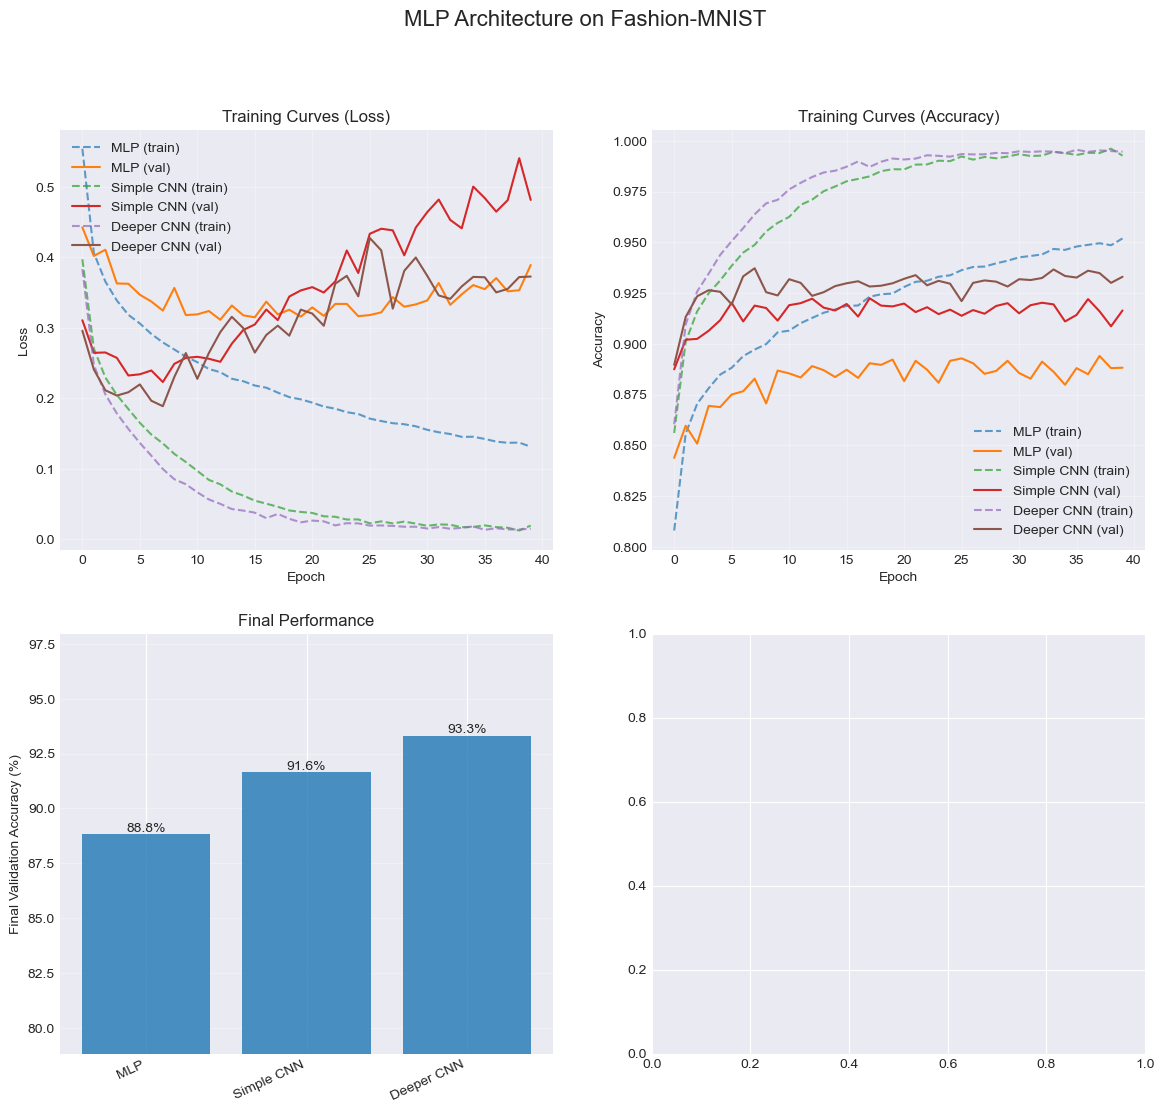

In [9]:
# get some results

def main():
    """
    Complete demonstration of MLPs on the FashionMNIST dataset.
    """
    print("="*80)
    print("MLP PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    # 1. Load Fashion-MNIST data
    # set seed
    torch.manual_seed(42)
    print("\n1. LOADING FASHION-MNIST DATA")
    transform = transforms.Compose([transforms.ToTensor()])

    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # split the training data into train and validation sets
    val_size = 5000
    train_size = len(train_dataset) - val_size
    train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

    # Create DataLoaders

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # print to see the length of the datasets
    print("\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(test_dataset)}")

    # print to see the length of the datasets
    print("\n===DIMENSIONS AFTER SPLIT===")
    print(f"Training samples: train_ds = {len(train_ds)}")
    print(f"Validation samples: val_ds = {len(val_ds)}")
    print(f"Test samples: test_dataset = {len(test_dataset)}")


    # 2. Architecture comparison
    results = compare_architectures(train_loader, val_loader)

    # 3. Visualize results
    visualize_training_results(results)




if __name__ == "__main__":
    main()